In [29]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (15, 3)
plt.rcParams['font.family'] = 'sans-serif'

In [30]:
url = "https://raw.githubusercontent.com/pgarco/GESISPython2025/refs/heads/main/data/imdb.csv"
df = pd.read_csv(url, parse_dates=True, index_col='year')
df[:5]

,name,movie_rated,run_length,genres,release_date,rating,num_raters,num_reviews
year,,,,,,,,
2010-01-01,Inception,PG-13,2h 28min,Action; Adventure; Sci-Fi;,16 July 2010 (USA),8.8,1981675,3820
2001-01-01,The Lord of the Rings: The Fellowship of the Ring,PG-13,2h 58min,Action; Adventure; Drama;,19 December 2001 (USA),8.8,1609165,5365
2003-01-01,The Lord of the Rings: The Return of the King,PG-13,3h 21min,Adventure; Drama; Fantasy;,17 December 2003 (USA),8.9,1593859,3681
2012-01-01,The Dark Knight Rises,PG-13,2h 44min,Action; Adventure;,20 July 2012 (USA),8.4,1470329,2979
2002-01-01,The Lord of the Rings: The Two Towers,PG-13,2h 59min,Adventure; Drama; Fantasy;,18 December 2002 (USA),8.7,1440188,2559


# String operations

You'll see that the genres column has a number of different movie genres. This is going to make it a bit trickier for us to find all Comedy movies, because the tricks we used in previous notebooks won't work:

In [31]:
df[df['genres'] == 'Drama']

,name,movie_rated,run_length,genres,release_date,rating,num_raters,num_reviews
year,,,,,,,,


Instead we can look for genres that contain the string Comedy

In [32]:
df[df['genres'].str.contains('Comedy', case=False, na=False)]

,name,movie_rated,run_length,genres,release_date,rating,num_raters,num_reviews
year,,,,,,,,
2014-01-01,Guardians of the Galaxy,PG-13,2h 1min,Action; Adventure; Comedy;,1 August 2014 (USA),8.0,1017405,1390
1985-01-01,Back to the Future,PG,1h 56min,Adventure; Comedy; Sci-Fi;,3 July 1985 (USA),8.5,1015004,1176
2003-01-01,Finding Nemo,G,1h 40min,Animation; Adventure; Comedy;,30 May 2003 (USA),8.1,922080,968
2009-01-01,Up,PG,1h 36min,Animation; Adventure; Comedy;,29 May 2009 (USA),8.2,905044,891
2016-01-01,Deadpool,R,1h 48min,Action; Adventure; Comedy;,12 February 2016 (USA),8.0,876091,1440
...,...,...,...,...,...,...,...,...
1975-01-01,Love and Death,PG,1h 25min,Comedy; War;,18 July 1975 (Canada),7.7,34959,118
1979-01-01,1941,PG,1h 58min,Action; Comedy; War;,14 December 1979 (USA),5.8,30625,252
1942-01-01,To Be or Not to Be,Passed,1h 39min,Comedy; War;,6 March 1942 (USA),8.2,26579,138


In [33]:
# Filter rows where both 'comedy' and 'war' appear in the genre string
war_comedy = df[df['genres'].str.contains('Comedy') & df['genres'].str.contains('Action')]

# Display results
print(war_comedy[['name', 'genres']])

                                           name                       genres
year                                                                        
2014-01-01              Guardians of the Galaxy  Action; Adventure; Comedy; 
2016-01-01                             Deadpool  Action; Adventure; Comedy; 
2014-01-01         Kingsman: The Secret Service  Action; Adventure; Comedy; 
2017-01-01                       Thor: Ragnarok  Action; Adventure; Comedy; 
2015-01-01                              Ant-Man  Action; Adventure; Comedy; 
2017-01-01       Guardians of the Galaxy Vol. 2  Action; Adventure; Comedy; 
2010-01-01                             Megamind  Animation; Action; Comedy; 
2017-01-01                        American Made  Action; Biography; Comedy; 
1998-01-01  Lock, Stock and Two Smoking Barrels      Action; Comedy; Crime; 
2010-01-01                             Kick-Ass      Action; Comedy; Crime; 
2012-01-01                       21 Jump Street      Action; Comedy; Crime; 

We can also split our genres into a list, which will make it easier to play with:

In [34]:
# Split genres into lists
df['genre_list'] = df['genres'].str.split(';')

# Remove extra whitespace
df['genre_list'] = df['genre_list'].apply(lambda x: [g.strip() for g in x])

# Explode into separate rows
df_exploded = df.explode('genre_list')

In [35]:
df_exploded

,name,movie_rated,run_length,genres,release_date,rating,num_raters,num_reviews,genre_list
year,,,,,,,,,
2010-01-01,Inception,PG-13,2h 28min,Action; Adventure; Sci-Fi;,16 July 2010 (USA),8.8,1981675,3820,Action
2010-01-01,Inception,PG-13,2h 28min,Action; Adventure; Sci-Fi;,16 July 2010 (USA),8.8,1981675,3820,Adventure
2010-01-01,Inception,PG-13,2h 28min,Action; Adventure; Sci-Fi;,16 July 2010 (USA),8.8,1981675,3820,Sci-Fi
2010-01-01,Inception,PG-13,2h 28min,Action; Adventure; Sci-Fi;,16 July 2010 (USA),8.8,1981675,3820,
2001-01-01,The Lord of the Rings: The Fellowship of the Ring,PG-13,2h 58min,Action; Adventure; Drama;,19 December 2001 (USA),8.8,1609165,5365,Action
...,...,...,...,...,...,...,...,...,...
2008-01-01,Stop-Loss,R,1h 52min,Drama; War;,28 March 2008 (USA),6.4,19456,102,
2004-01-01,The Alamo,PG-13,2h 17min,Drama; History; War;,9 April 2004 (USA),6.0,19290,306,Drama
2004-01-01,The Alamo,PG-13,2h 17min,Drama; History; War;,9 April 2004 (USA),6.0,19290,306,History


In [36]:
df_exploded = df_exploded[df_exploded['genre_list'] != '']

In [37]:
#Another way to do this
df = df[(df != '').any(axis=1)]

In [38]:
df_exploded

,name,movie_rated,run_length,genres,release_date,rating,num_raters,num_reviews,genre_list
year,,,,,,,,,
2010-01-01,Inception,PG-13,2h 28min,Action; Adventure; Sci-Fi;,16 July 2010 (USA),8.8,1981675,3820,Action
2010-01-01,Inception,PG-13,2h 28min,Action; Adventure; Sci-Fi;,16 July 2010 (USA),8.8,1981675,3820,Adventure
2010-01-01,Inception,PG-13,2h 28min,Action; Adventure; Sci-Fi;,16 July 2010 (USA),8.8,1981675,3820,Sci-Fi
2001-01-01,The Lord of the Rings: The Fellowship of the Ring,PG-13,2h 58min,Action; Adventure; Drama;,19 December 2001 (USA),8.8,1609165,5365,Action
2001-01-01,The Lord of the Rings: The Fellowship of the Ring,PG-13,2h 58min,Action; Adventure; Drama;,19 December 2001 (USA),8.8,1609165,5365,Adventure
...,...,...,...,...,...,...,...,...,...
2008-01-01,Stop-Loss,R,1h 52min,Drama; War;,28 March 2008 (USA),6.4,19456,102,Drama
2008-01-01,Stop-Loss,R,1h 52min,Drama; War;,28 March 2008 (USA),6.4,19456,102,War
2004-01-01,The Alamo,PG-13,2h 17min,Drama; History; War;,9 April 2004 (USA),6.0,19290,306,Drama


Now we are armed with a treasure trove of fun things. Let's see what the most popular genre is:

<Axes: xlabel='genre_list'>

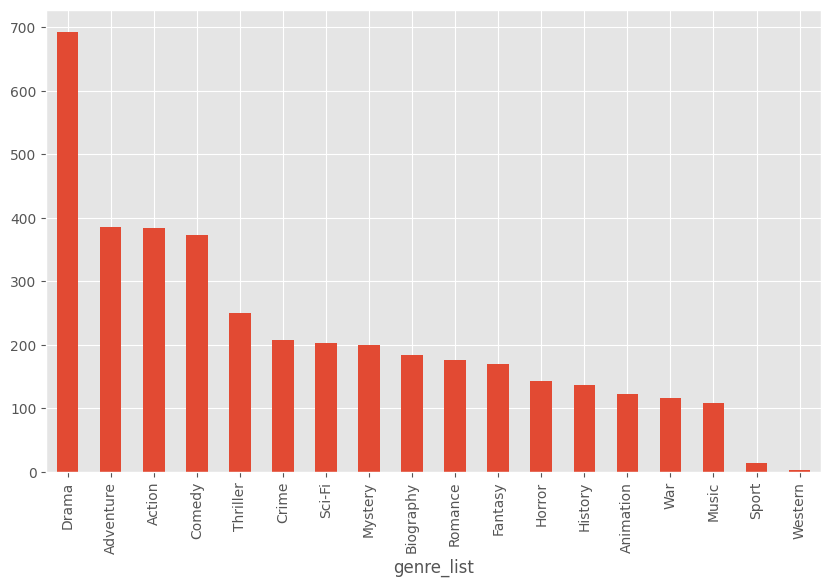

In [39]:
df_exploded['genre_list'].value_counts().plot(kind='bar', figsize=(10,6))

Let's build a function that asks the user for a genre and returns the highest rated films of each genre:

In [50]:
import pandas as pd

def top_rated_by_genre_exploded(df_exploded, genre, top_n=5):
    genre = genre.lower().strip()

    # Filter rows where genre matches
    filtered = df_exploded[df_exploded['genre_list'].str.lower().str.strip() == genre]

    if filtered.empty:
        print(f"😕 No movies found for genre: '{genre}'")
        return

    # Group by title and take the max rating per movie
    top_movies = (
        filtered.groupby('name', as_index=False)
        .agg({'rating': 'max'})
        .sort_values(by='rating', ascending=False)
        .head(top_n)
    )

    print(f"\n🎥 Top {top_n} movies in genre: {genre.title()}")
    print(top_movies.to_string(index=False))




In [51]:
while True:
    user_input = input("\nEnter a genre to see top-rated movies (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        print("Goodbye! 🎬")
        break
    top_rated_by_genre_exploded(df_exploded, user_input)



Enter a genre to see top-rated movies (or type 'exit' to quit): war

🎥 Top 5 movies in genre: War
                  name  rating
       The Mountain II     8.9
   Saving Private Ryan     8.6
Grave of the Fireflies     8.5
            Casablanca     8.5
        Paths of Glory     8.4

Enter a genre to see top-rated movies (or type 'exit' to quit): comedy

🎥 Top 5 movies in genre: Comedy
              name  rating
 Life Is Beautiful     8.6
          Parasite     8.6
  The Intouchables     8.5
Back to the Future     8.5
          3 Idiots     8.4

Enter a genre to see top-rated movies (or type 'exit' to quit): explosions
😕 No movies found for genre: 'explosions'

Enter a genre to see top-rated movies (or type 'exit' to quit): exit
Goodbye! 🎬
